In [7]:
import wfdb

path = "/Users/neeldavuluri/uu_project1/mit-bih-arrhythmia-database-1.0.0"

record = wfdb.rdrecord(path + "/100")
ann = wfdb.rdann(path + "/100", "atr")

print(record.sig_name, record.fs)

['MLII', 'V5'] 360


In [24]:
import wfdb
import os

path = "/Users/neeldavuluri/uu_project1/mit-bih-arrhythmia-database-1.0.0"

with open(path + "/RECORDS", "r") as f:
    records = f.read().splitlines()

print(records)

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [25]:
import pandas as pd

info = []

for rec in records:
    header = wfdb.rdheader(path + "/" + rec)
    info.append([rec, header.sig_name, header.fs, header.sig_len])

df = pd.DataFrame(info, columns=["Record", "Leads", "Sampling Rate", "Samples"])
df

,Record,Leads,Sampling Rate,Samples
0,100,"[MLII, V5]",360,650000
1,101,"[MLII, V1]",360,650000
2,102,"[V5, V2]",360,650000
3,103,"[MLII, V2]",360,650000
4,104,"[V5, V2]",360,650000
5,105,"[MLII, V1]",360,650000
6,106,"[MLII, V1]",360,650000
7,107,"[MLII, V1]",360,650000
8,108,"[MLII, V1]",360,650000
9,109,"[MLII, V1]",360,650000


In [ ]:
##heartbeat types

from collections import Counter

all_beats = []

for rec in records:
    ann = wfdb.rdann(path + "/" + rec, "atr")
    all_beats.extend(ann.symbol)

beat_counts = Counter(all_beats)
beat_counts


Counter({'N': 75052,
         'L': 8075,
         'R': 7259,
         'V': 7130,
         '/': 7028,
         'A': 2546,
         '+': 1291,
         'f': 982,
         'F': 803,
         '~': 616,
         '!': 472,
         '"': 437,
         'j': 229,
         'x': 193,
         'a': 150,
         '|': 132,
         'E': 106,
         'J': 83,
         'Q': 33,
         'e': 16,
         '[': 6,
         ']': 6,
         'S': 2})

In [28]:
arrhythmia_summary = []

for rec in records:
    ann = wfdb.rdann(path + "/" + rec, "atr")
    counts = pd.Series(ann.symbol).value_counts()
    arrhythmia_summary.append([
        rec,
        counts.get('N', 0),
        counts.get('V', 0),   # Ventricular arrhythmia
        counts.get('A', 0)    # Atrial arrhythmia
    ])

pd.DataFrame(arrhythmia_summary, columns=["Record","Normal Beats","V Beats","A Beats"])

,Record,Normal Beats,V Beats,A Beats
0,100,2239,1,33
1,101,1860,0,3
2,102,99,4,0
3,103,2082,0,2
4,104,163,2,0
5,105,2526,41,0
6,106,1507,520,0
7,107,0,59,0
8,108,1739,17,4
9,109,0,38,0


🫀 What Each Column Means
Column	Meaning
Record	The patient recording ID (e.g., 100, 208)
Normal Beats	Count of normal heartbeats (N)
V Beats	Count of ventricular arrhythmia beats (V) — these are dangerous irregular beats
A Beats	Count of atrial arrhythmia beats (A) — these imply atrial rhythm problems

So for each recording, we see how healthy or abnormal the rhythm is.

🎯 How to Interpret the Patterns

Records with mostly Normal beats → Healthy rhythm

Records with many V beats → Ventricular arrhythmia

Records with many A beats → Atrial arrhythmia

✅ Examples
Record	Interpretation
100	2239 normal beats, 1 ventricular beat → Very stable normal rhythm
106	1507 normal, 520 ventricular → Strong ventricular arrhythmia
118	0 normal, 16 ventricular, 96 atrial → Primary atrial arrhythmia
208	1586 normal, 992 ventricular → Severe ventricular arrhythmia
232	0 normal, 0 ventricular, 1382 atrial → Pure atrial fibrillation-like rhythm

In [18]:
import numpy as np

R_peaks = ann.sample              # sample index of each heartbeat
fs = record.fs                    # sampling rate = 360 Hz

RR_intervals = np.diff(R_peaks) / fs   # convert from samples → seconds

print("First 15 RR Intervals:", RR_intervals[:15])
print("Number of beats:", len(RR_intervals))

First 15 RR Intervals: [0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444 0.81111111 0.78888889
 0.77222222 0.83888889 0.85555556]
Number of beats: 2273


In [13]:
from sklearn.neighbors import KernelDensity

RR = RR_intervals.reshape(-1, 1)

kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(RR)

In [19]:
synthetic_RR = kde.sample(500).flatten()
print("First 20 synthetic intervals:", synthetic_RR[:20])

First 20 synthetic intervals: [0.73938226 0.94880845 0.75499451 0.88216824 0.79209196 0.77314246
 0.72954171 0.99844581 0.74726728 0.69923058 0.81051531 0.73247838
 0.87609636 0.84246306 0.72700561 0.86760434 0.75545961 0.7018723
 0.76928954 0.71886408]


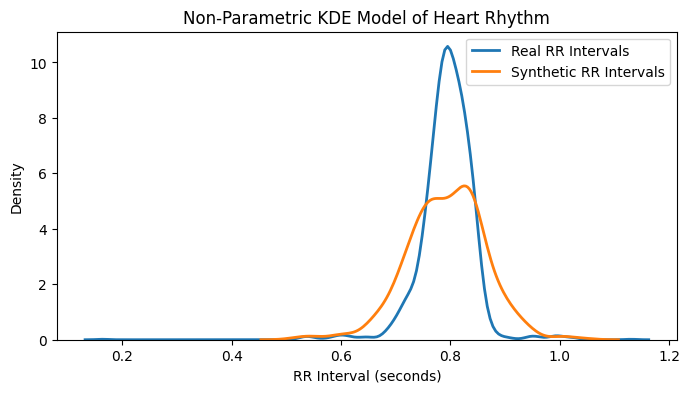

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.kdeplot(RR_intervals, label="Real RR Intervals", linewidth=2)
sns.kdeplot(synthetic_RR, label="Synthetic RR Intervals", linewidth=2)
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Density")
plt.title("Non-Parametric KDE Model of Heart Rhythm")
plt.legend()
plt.show()

The blue curve (Real RR Intervals) is very sharp and high-peaked.
That means:

This subject had a very stable heart rhythm

Heartbeats occur at a consistent interval (~0.78 seconds)

This is characteristic of normal sinus rhythm

The orange curve (Synthetic RR Intervals) is broader and flatter, meaning:

The KDE model captured the central rhythm, but

It is adding more variability than the real heart actually had

This is because KDE smooths the empirical distribution

This difference tells us how our bandwidth choice controls realism vs variability.